# Homework 0 Part 2

**This is an individual assignment.**

---

## Custom Transformers

```scikit-learn``` offers many useful transformers, but you will likely need to write your own transformers for tasks such as custom cleanup operations or combining specific attributes.

To have your transformer working seamlessly with ```scikit-learn```, all you need to do is create a class and implement three methods: ```fit()``` (returning self), ```transform()```, and ```fit_transform()```.

You can get the last one for free by simply adding ```TransformerMixin``` as your base class. If you add ```BaseEstimator``` as a base class (and avoid ```*args``` and ```**kargs```) you will also get two extra methods (```get_params()``` and ```set_params()```) that will be useful for automatic hyperparameter tuning.

For example, for the dataset we discussed in lecture (California housing prices), we can build a transformer to add the custom attributes as follows:

````python
from sklearn.base import BaseEstimator, TransformerMixin 

rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6
# column indices for each respective attribute

class CombinedAttributesAdder(BaseEstimator, TransformerMixin): 
    def __init__ (self, add_bedrooms_per_room=True): # no *args or **kargs 
        self.add_bedrooms_per_room = add_bedrooms_per_room 
        #to be defined under method transform
        
    def fit(self, X, y=None): 
        return self # nothing else to do 
        
    def transform(self, X): 
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix] 
        population_per_household = X[:, population_ix] / X[:, households_ix] 
        if self.add_bedrooms_per_room: 
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix] 
        #concatenate the arrays and add them to feature matrix
        return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]
````

This transformer can later be added to a ```scikit-learn``` pipeline like this:

````python
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import StandardScaler 

num_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), 
                         ('attribs_adder', CombinedAttributesAdder()), 
                         ('std_scaler', StandardScaler())])
````

---

# Exercise 1 (40 points)

**In this question, you will be working with the [marathon time predictions dataset](https://www.kaggle.com/datasets/girardi69/marathon-time-predictions).**

### Attribute Description

1. **id**: simple counter (categorical/identifier).
2. **Marathon**: the Marathon name where the data were extracted (categorical).
3. **Name**: the athlete's name (categorical).
4. **Category**: the sex and age group of a runner (categorical).
    * MAM: Male Athletes under 40 years
    * WAM: Women under 40 years
    * M40, M45, M50, M55, ...: Male Athletes within the corresponding age bracket
5. **km4week**: total number of kilometers run in the last 4 weeks before the marathon, marathon included (numerical).
6. **sp4week**: average speed of the athlete in the last 4 training weeks, including slow and fast segments of training runs (numerical).
7. **CrossTraining**: indicates whether the runner also cycles or does triathlon training (categorical).
8. **Wall21**: ratio between the second-half and first-half splits of the marathon; a value close to 1 indicates an even pace, while a higher value indicates the runner "hit the wall" and slowed down substantially in the second half (numerical).
9. **MarathonTime**: the athlete's marathon finishing time, in hours (numerical). **This is the target value.**
10. **CATEGORY**: a categorical binning of the target value into finishing-time brackets (A: under 3h, B: 3h-3h20m, C: 3h20m-3h40m, D: 3h40m-4h).

In [ ]:
# Import libraries and magics
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')

**Answer the following questions:**

1. (1 point) **Load the data from the ```MarathonData.csv``` file with ```pandas```.**

2. (2 points) **Partition the data into training and test sets using an 80/20 random split. Fix random seed with ````random_state=0````**

3. (6 points) **Inspect the dataset for: (a) useless attributes, (b) missing data, (c) categorical attributes and how many categories it includes, and (d) numerical data. Decide and explain: (1) which attributes will be discarded, if any; (2) your approach to handling missing data, if there are any missing samples; (3) how to encode categorical attributes; and, (4) which scaler you will use for each numerical attribute.**

4. (16 points) **Build a custom transformer using the template provided at the top of this notebook to add the following new attribute to the dataframe:**
    * **Compute the ratio between ```km4week``` and ```sp4week``` (i.e., ```km4week``` / ```sp4week```) as a new attribute called ```pace_ratio```, which roughly captures how much slow/base mileage a runner logs relative to their training pace.**
    * **This transformer should also apply the cleanup decisions from question 3: drop the useless attributes (```id```, ```Marathon```, ```Name```, ```CrossTraining```, ```CATEGORY```), drop rows with a missing ```Category```, and cast ```Wall21``` to a numeric type (dropping rows where it cannot be cast).**

5. (10 points) **Build a ```ColumnTransformer``` pipeline to (1) append the new attribute for ```pace_ratio``` (and apply the cleanup decisions from question 3), (2) encode categorical attributes, and (3) impute (if needed) and scale numerical attributes.**

6. (5 points) **Apply the trained pipeline in (6) to the test set.**

---

# Exercise 2 (5 points)

**In this question, you will practice how to use HiPerGator and Git to maintain your code.**

1. (1 point) **Go to Open OnDemand at [ood.rc.ufl.edu](ood.rc.ufl.edu) and launch an interactive Jupyter session with 2 CPUs, 2 GPUs (keep the Cluster partition set to default and type "gpu:2" under the Generic Resource Request section), and 16 GB of RAM — this is the maximum allocation available per user. Include a screenshot of your Jupyter notebook card showing your GatorLink username (see example below).**

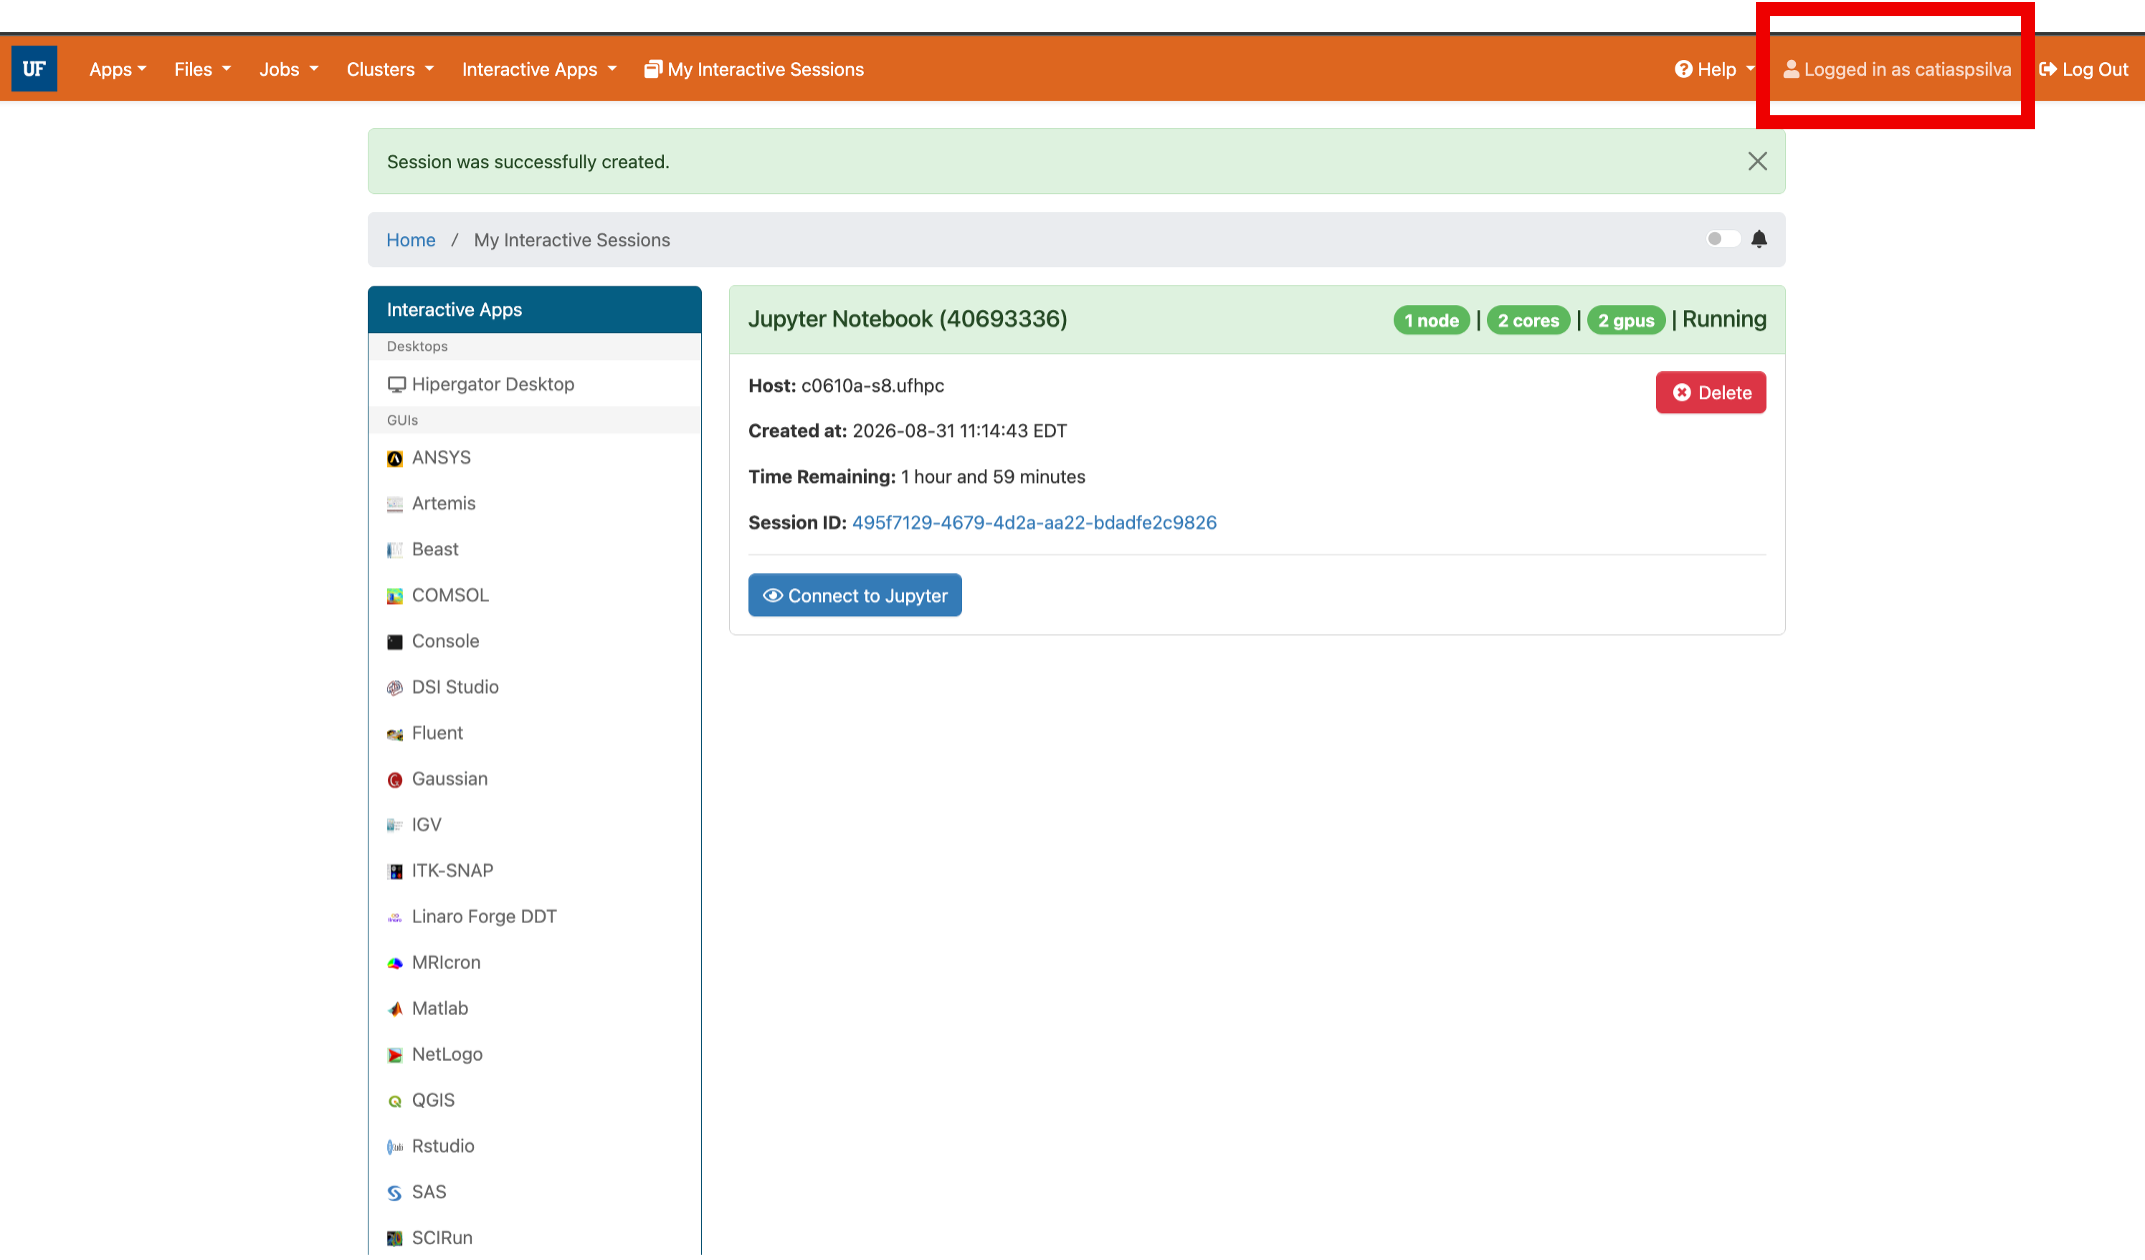

In [5]:
from IPython.display import Image
Image('figures/ood_rc.png', width=900)

2. (1 point) **Create a symbolic link to map the class blue directory in your homepage. Attach a screenshot to show that this link has been created. Example and instructions below.**

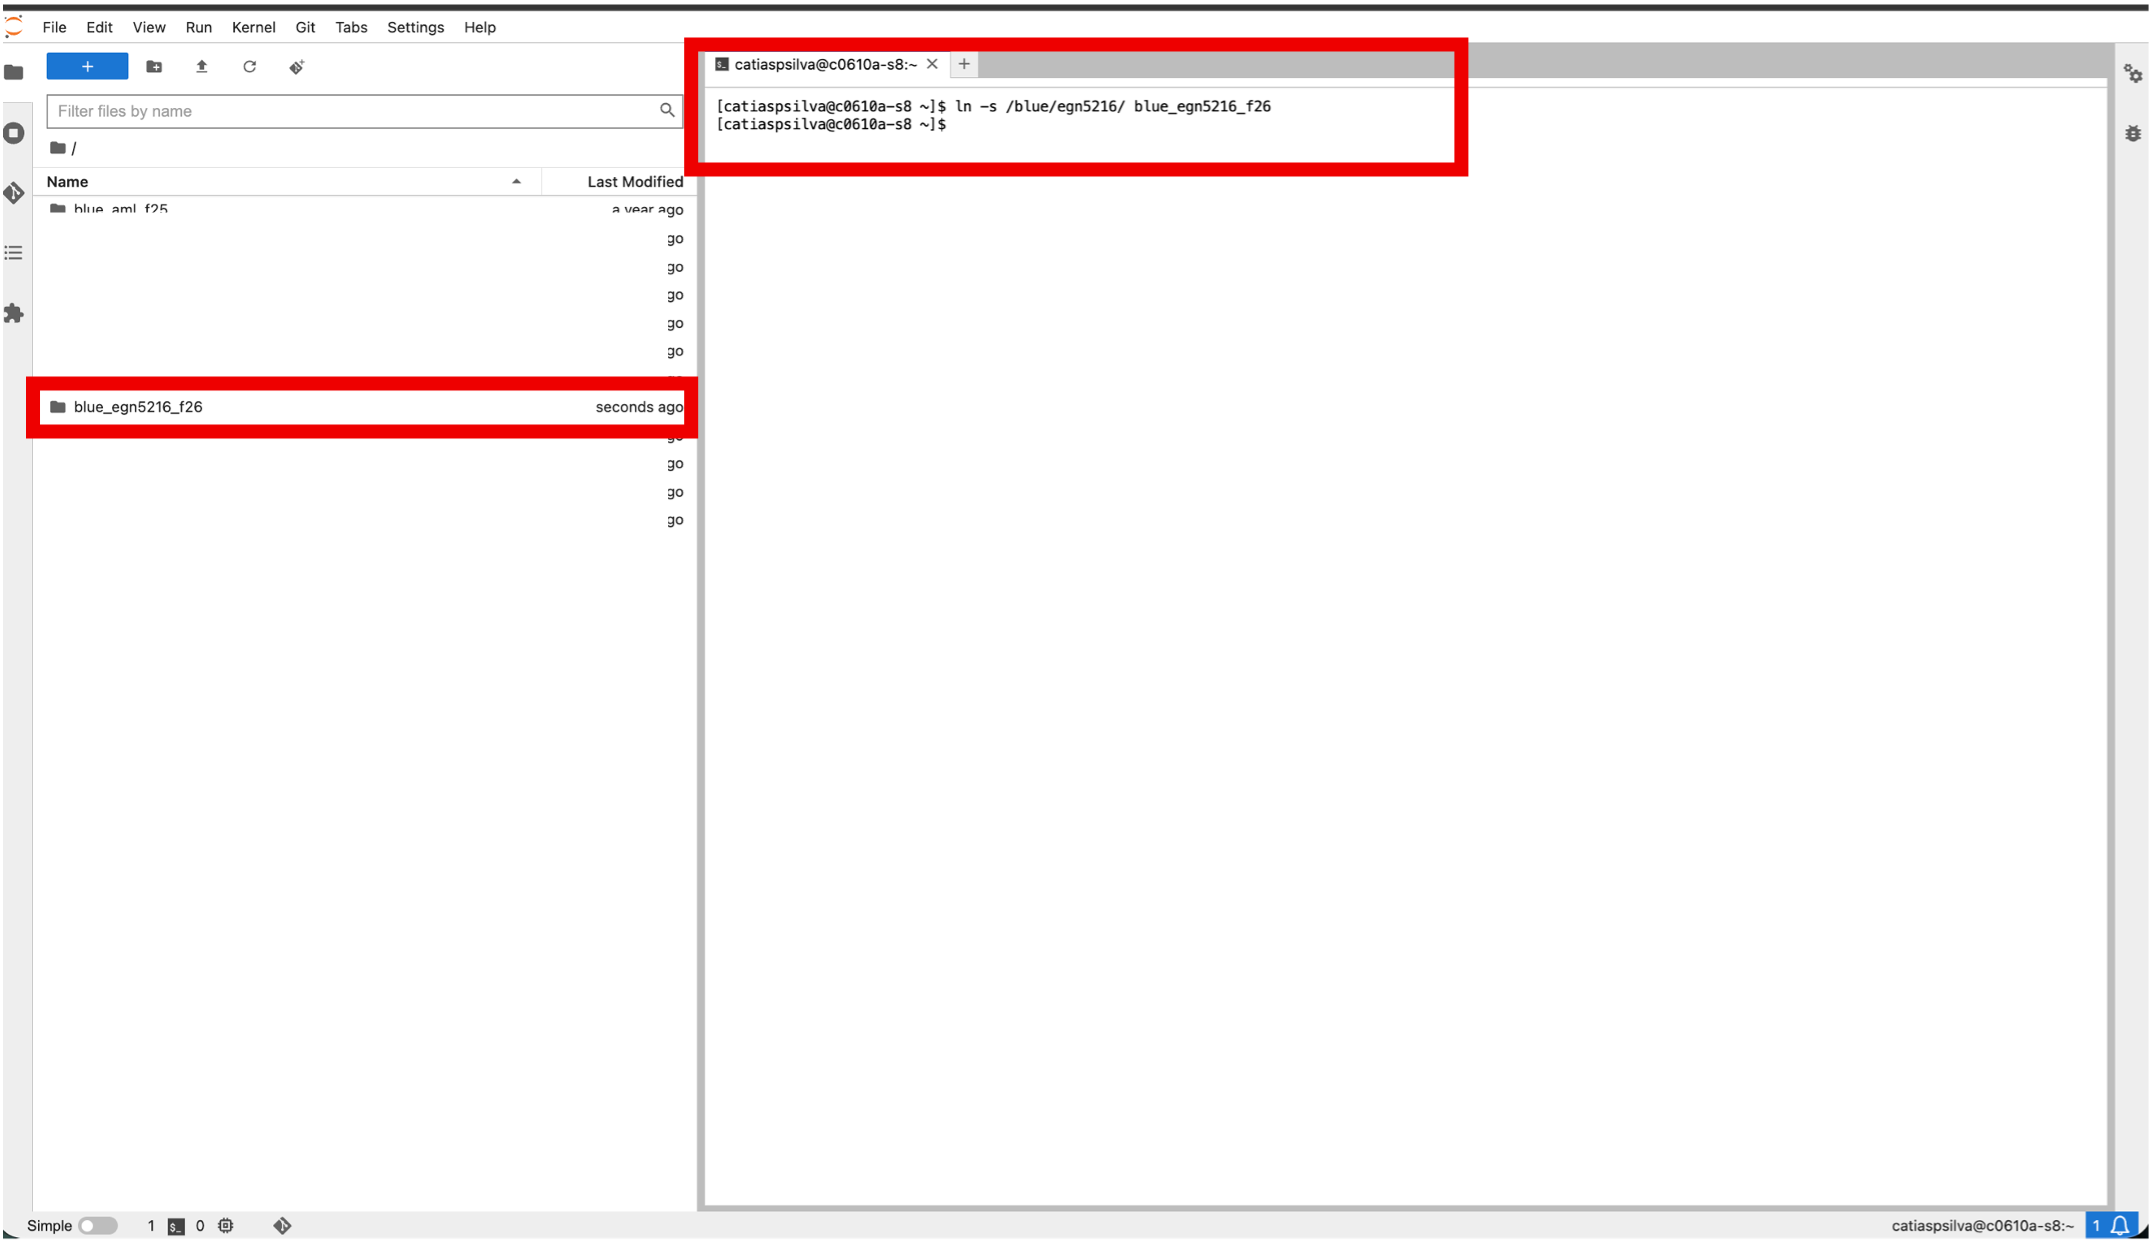

In [6]:
Image('figures/symbolic_link.png', width=900)

3. (1 point) **In the terminal change the directory to the egn5216 blue storage, ```cd /blue/egn5216/```. Next, if you don't see a folder with your GatorLink username, go ahead and create one, ```mkdir foldername```. Finally make sure your folder is only accessible to only you by changing its mode to 700, ```chmod 700 foldername```. Attach a screenshot with these steps. See example and instructions below.**

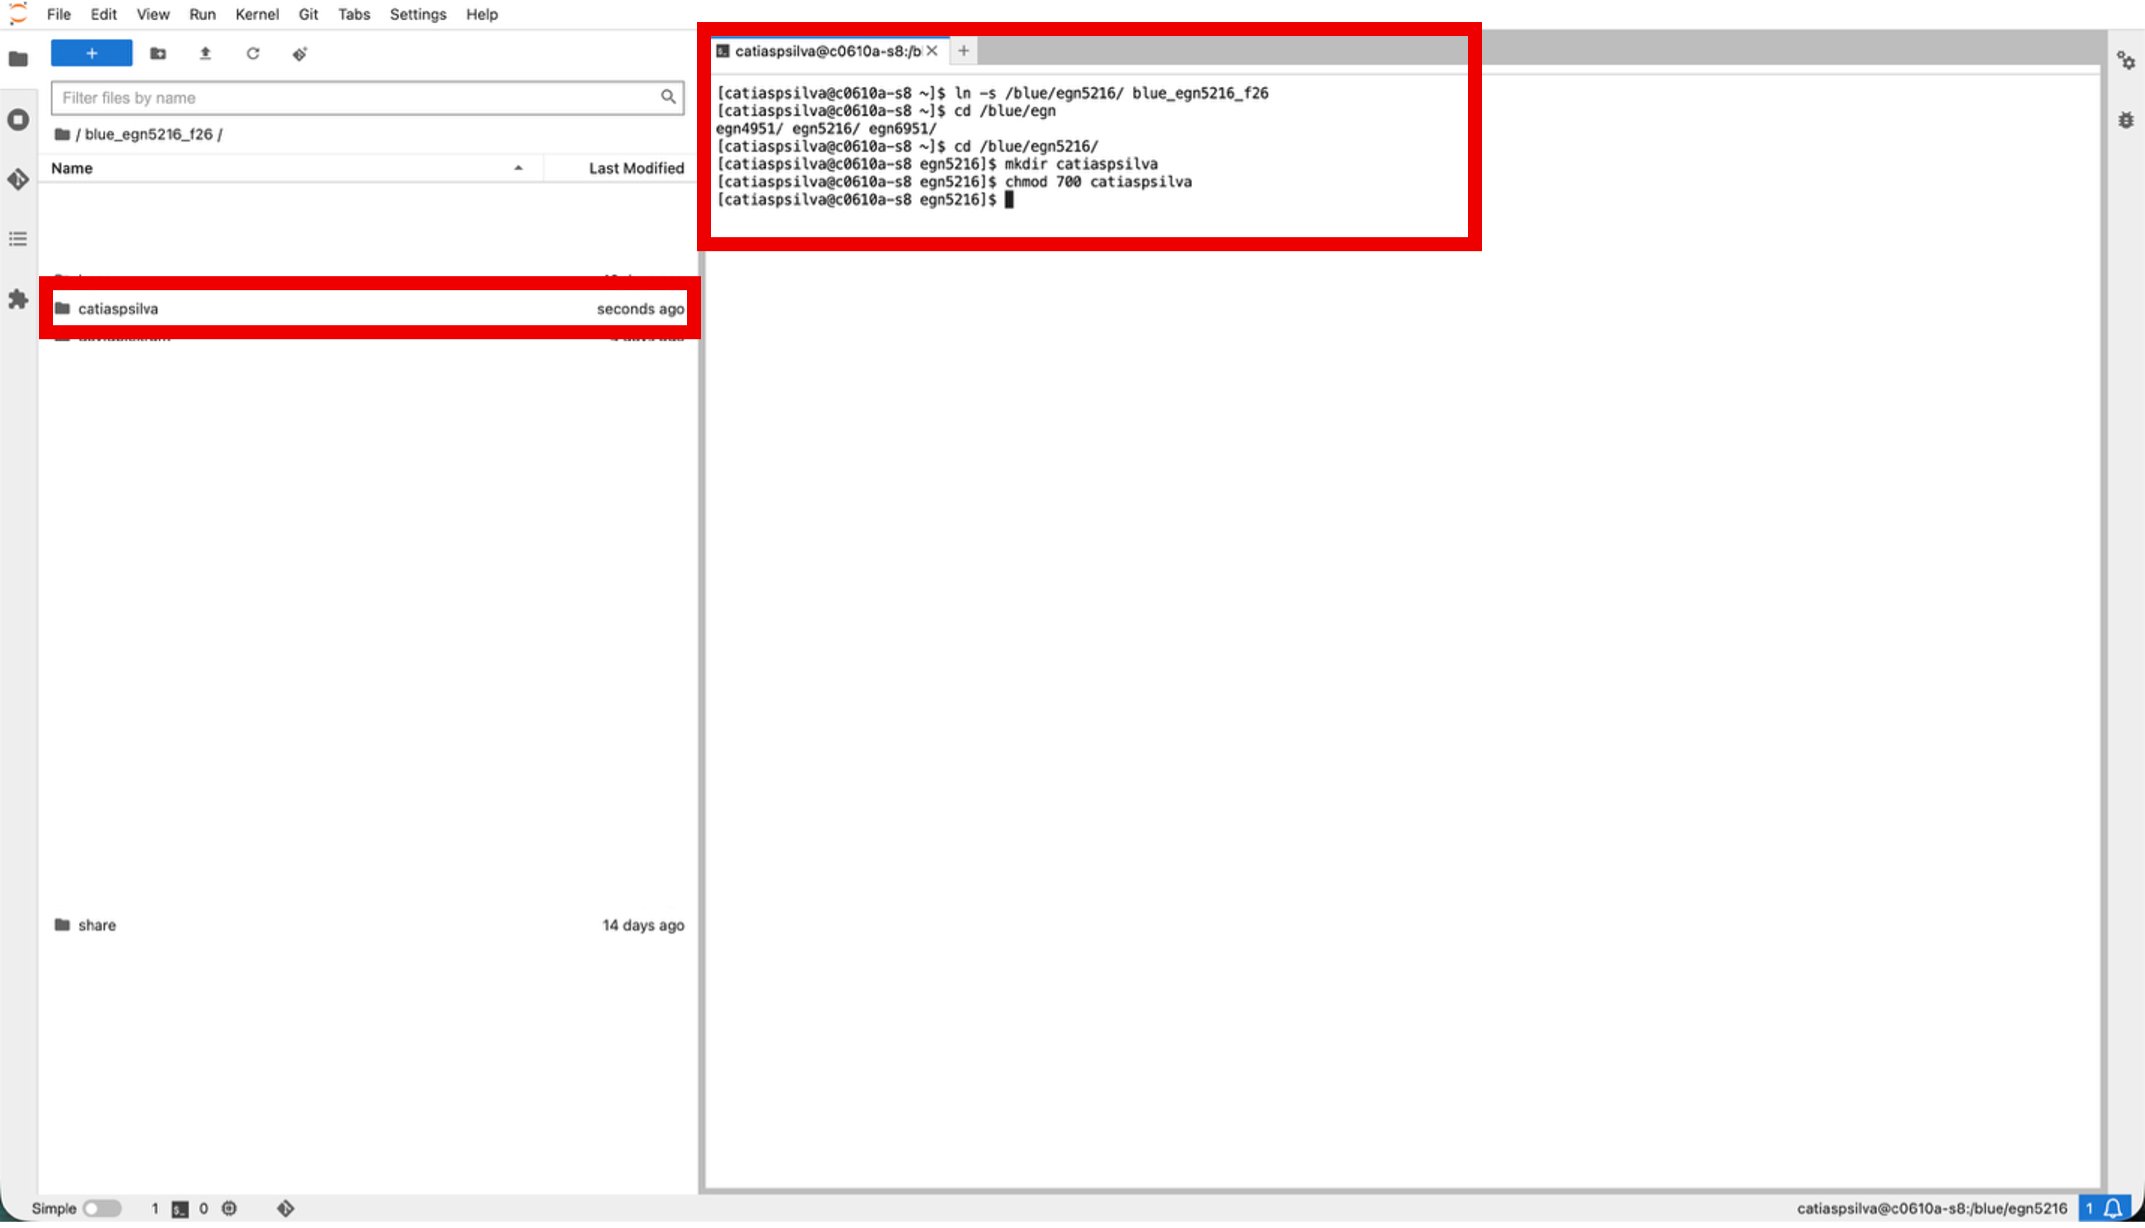

In [7]:
Image('figures/chmod700.png', width=900)

4. (2 points) **In the terminal change the directory to your folder, for me it's ```cd catiaspsilva/```. This is where you will clone ALL assignments. Set up your GitHub SSH key, and clone your homework 0 repository. Attach a screenshot with this step. See example and instructions below for cloning the repository.**

**For instructions on setting up your GitHub SSH key, enroll in free ["Introduction to Git & GitHub workshop"](https://ufl.instructure.com/enroll/TWR9LR), select Module 3, and watch the video titled "Set up SSH Key" for a step-by-step hands-on demonstration.**

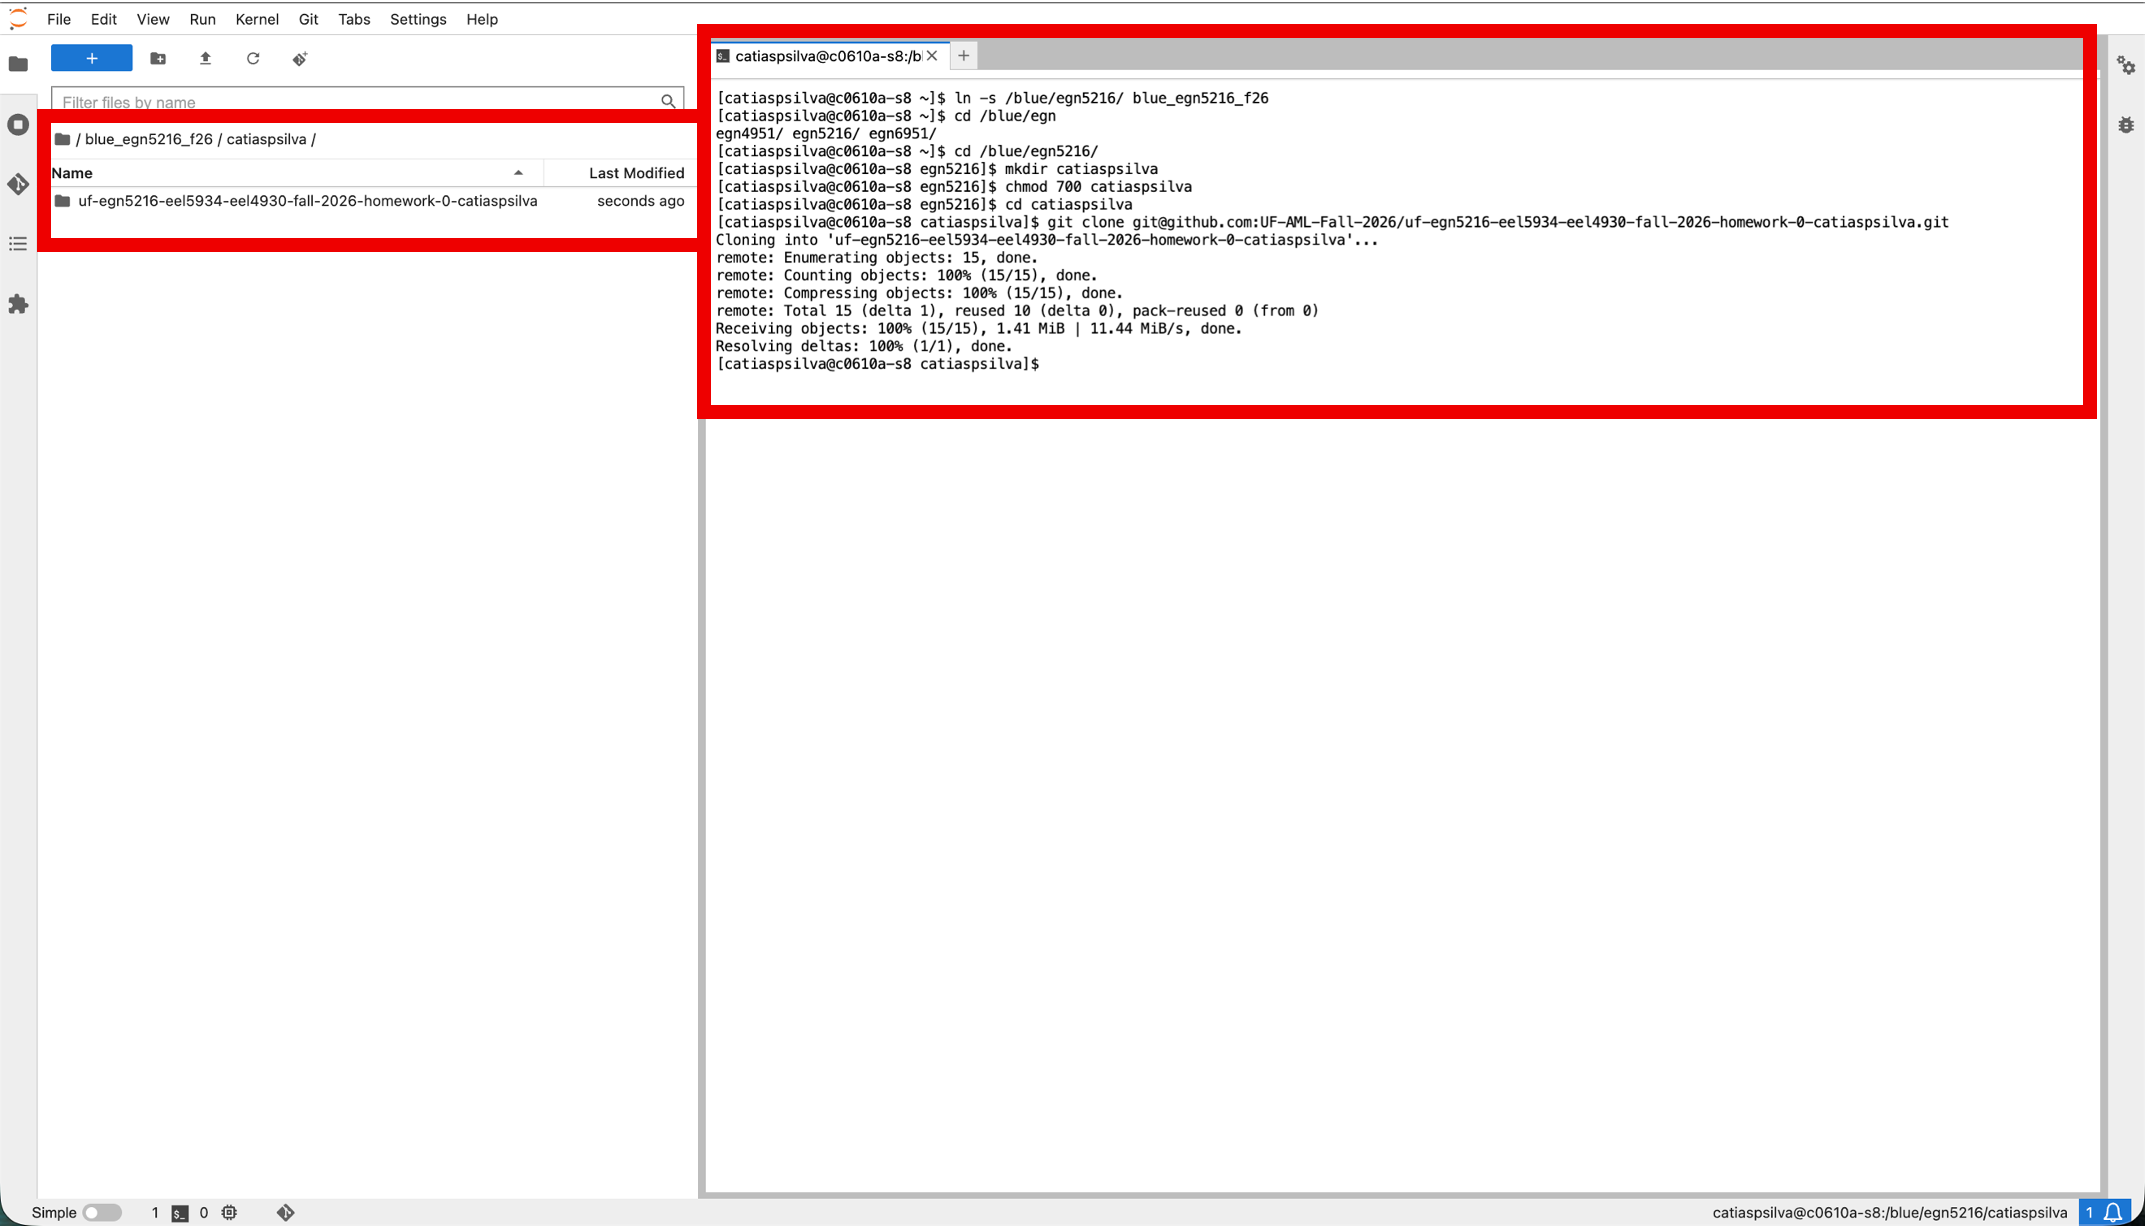

In [8]:
Image('figures/cloning_repo.png', width=900)

---

# On-Time (5 points)

Push a notebook containing your answers to your GitHub repository before the assignment deadline to avoid a late penalty.

---